In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
from google.colab import files
uploaded = files.upload()

Saving India_Districts_Crop_Production_Processed.csv to India_Districts_Crop_Production_Processed (2).csv


In [35]:
import pandas as pd

df = pd.read_csv("/content/India_Districts_Crop_Production_Processed.csv")
df.head()

,Country,State,District,Crop,Year,Production,State_Encoded,District_Encoded,Crop_Encoded,Ind_adm2_ID,...,Longitude,Nitrogen (kg/ha),Phosphorus (kg/ha),Potassium (kg/ha),Organic Carbon (%),Soil pH,weather_temp_c,weather_humidity_pct,weather_precip_mm,weather_sunshine_hours
0,India,Andhra Pradesh,Adilabad,Bajra,2021-22,0.0,0,0,0,2,...,78.813212,280.0,10.0,280.0,0.5,7.5,26.7,88,0.0,0.825228
1,India,Andhra Pradesh,Anantapur,Bajra,2021-22,0.0,0,17,0,3,...,77.460158,280.0,10.0,280.0,0.5,7.5,25.9,68,0.0,10.049725
2,India,Andhra Pradesh,Chittoor,Bajra,2021-22,10.0,0,88,0,4,...,78.927639,280.0,10.0,280.0,0.5,7.5,25.7,79,0.1,6.677400
3,India,Andhra Pradesh,East Godavari,Bajra,2021-22,0.0,0,124,0,6,...,82.243207,280.0,10.0,280.0,0.5,7.5,29.6,80,0.1,9.751767
4,India,Andhra Pradesh,Guntur,Bajra,2021-22,0.0,0,159,0,7,...,80.586576,280.0,10.0,280.0,0.5,7.5,29.5,79,0.3,5.329769


# EDA

In [36]:
y = df['Production']   # Target

In [22]:
df.shape

(27303, 21)

In [23]:
df.columns


Index(['Country', 'State', 'District', 'Crop', 'Year', 'Production',
       'State_Encoded', 'District_Encoded', 'Crop_Encoded', 'Ind_adm2_ID',
       'Latitude', 'Longitude', 'Nitrogen (kg/ha)', 'Phosphorus (kg/ha)',
       'Potassium (kg/ha)', 'Organic Carbon (%)', 'Soil pH', 'weather_temp_c',
       'weather_humidity_pct', 'weather_precip_mm', 'weather_sunshine_hours'],
      dtype='object')

In [24]:
df.describe()

,Production,State_Encoded,District_Encoded,Crop_Encoded,Ind_adm2_ID,Latitude,Longitude,Nitrogen (kg/ha),Phosphorus (kg/ha),Potassium (kg/ha),Organic Carbon (%),Soil pH,weather_temp_c,weather_humidity_pct,weather_precip_mm,weather_sunshine_hours
count,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000
mean,90.742409,14.933194,236.273486,9.000000,290.025052,23.449032,81.058574,309.812109,20.835073,210.855950,0.542276,6.656576,27.434864,80.217119,0.072443,7.362799
std,249.707018,8.521511,137.272490,5.477326,168.406949,5.434659,6.297315,86.364934,6.717808,79.261456,0.093712,1.162461,3.365981,9.464690,0.178937,3.583898
min,0.000000,0.000000,0.000000,0.000000,2.000000,8.183466,68.821923,280.000000,10.000000,120.000000,0.500000,4.500000,1.900000,53.000000,0.000000,0.000000
25%,0.000000,8.000000,117.000000,4.000000,139.000000,20.890803,76.393541,280.000000,10.000000,120.000000,0.500000,5.500000,26.700000,72.000000,0.000000,4.695328
50%,0.000000,15.000000,236.000000,9.000000,291.000000,24.588772,79.319487,280.000000,25.000000,280.000000,0.500000,7.500000,28.100000,82.000000,0.000000,8.347325
75%,30.000000,23.000000,355.000000,14.000000,436.000000,26.833880,84.920812,280.000000,25.000000,280.000000,0.500000,7.500000,29.500000,87.000000,0.100000,10.684931
max,3090.000000,28.000000,474.000000,18.000000,588.000000,34.273129,96.596708,560.000000,25.000000,280.000000,0.750000,7.500000,32.000000,100.000000,1.500000,11.725317


In [25]:
# Checking missing values of the dataset in each column
df.isnull().sum()

,0
Country,0
State,0
District,0
Crop,0
Year,0
Production,0
State_Encoded,0
District_Encoded,0
Crop_Encoded,0
Ind_adm2_ID,0


In [26]:
print(df.nunique())

Country                     1
State                      29
District                  475
Crop                       19
Year                        3
Production                211
State_Encoded              29
District_Encoded          475
Crop_Encoded               19
Ind_adm2_ID               479
Latitude                  479
Longitude                 479
Nitrogen (kg/ha)            2
Phosphorus (kg/ha)          2
Potassium (kg/ha)           2
Organic Carbon (%)          2
Soil pH                     4
weather_temp_c            107
weather_humidity_pct       44
weather_precip_mm          14
weather_sunshine_hours    444
dtype: int64


In [37]:
X = df.copy()

cols_to_drop = [
    'Country',
    'State',
    'District',
    'Crop',
    'Ind_adm2_ID',
    'District_Encoded',
    'Nitrogen (kg/ha)',
    'Phosphorus (kg/ha)',
    'Potassium (kg/ha)',
    'Organic Carbon (%)',
    'Production'   # remove from X ONLY
]

X.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [38]:
X['Year'] = X['Year'].str.split('-').str[0].astype(int)

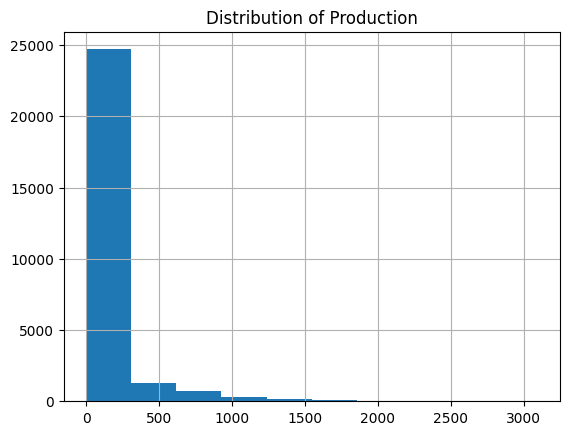

In [40]:
import matplotlib.pyplot as plt

y.hist()
plt.title("Distribution of Production")
plt.show()

In [42]:
import numpy as np

y_log = np.log1p(y)

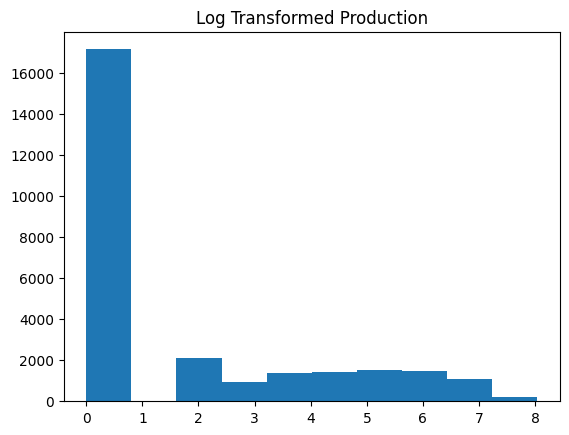

In [43]:
import matplotlib.pyplot as plt

plt.hist(y_log)
plt.title("Log Transformed Production")
plt.show()

In [39]:
print(X.columns)

Index(['Year', 'State_Encoded', 'Crop_Encoded', 'Latitude', 'Longitude',
       'Soil pH', 'weather_temp_c', 'weather_humidity_pct',
       'weather_precip_mm', 'weather_sunshine_hours'],
      dtype='object')


In [27]:
# Make a copy
df_clean = df.copy()

# Final columns to drop
cols_to_drop = [
    'Country',              # only 1 value
    'State',                # raw (encoded exists)
    'District',             # raw (encoded exists)
    'Crop',                 # raw (encoded exists)
    'Ind_adm2_ID',          # useless ID
    'District_Encoded',     # high cardinality (optional but we drop here)

    # Low variance nutrient features
    'Nitrogen (kg/ha)',
    'Phosphorus (kg/ha)',
    'Potassium (kg/ha)',
    'Organic Carbon (%)',

    # Target leakage (ONLY if predicting Yield)
    'Production'
]

# Drop columns
df_clean.drop(columns=cols_to_drop, inplace=True)

# Check result
print("Remaining columns:\n", df_clean.columns)

Remaining columns:
 Index(['Year', 'State_Encoded', 'Crop_Encoded', 'Latitude', 'Longitude',
       'Soil pH', 'weather_temp_c', 'weather_humidity_pct',
       'weather_precip_mm', 'weather_sunshine_hours'],
      dtype='object')


In [28]:
df_clean.shape
df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27303 entries, 0 to 27302
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    27303 non-null  object 
 1   State_Encoded           27303 non-null  int64  
 2   Crop_Encoded            27303 non-null  int64  
 3   Latitude                27303 non-null  float64
 4   Longitude               27303 non-null  float64
 5   Soil pH                 27303 non-null  float64
 6   weather_temp_c          27303 non-null  float64
 7   weather_humidity_pct    27303 non-null  int64  
 8   weather_precip_mm       27303 non-null  float64
 9   weather_sunshine_hours  27303 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 2.1+ MB


,State_Encoded,Crop_Encoded,Latitude,Longitude,Soil pH,weather_temp_c,weather_humidity_pct,weather_precip_mm,weather_sunshine_hours
count,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000,27303.000000
mean,14.933194,9.000000,23.449032,81.058574,6.656576,27.434864,80.217119,0.072443,7.362799
std,8.521511,5.477326,5.434659,6.297315,1.162461,3.365981,9.464690,0.178937,3.583898
min,0.000000,0.000000,8.183466,68.821923,4.500000,1.900000,53.000000,0.000000,0.000000
25%,8.000000,4.000000,20.890803,76.393541,5.500000,26.700000,72.000000,0.000000,4.695328
50%,15.000000,9.000000,24.588772,79.319487,7.500000,28.100000,82.000000,0.000000,8.347325
75%,23.000000,14.000000,26.833880,84.920812,7.500000,29.500000,87.000000,0.100000,10.684931
max,28.000000,18.000000,34.273129,96.596708,7.500000,32.000000,100.000000,1.500000,11.725317


In [31]:
df_clean['Year'] = df_clean['Year'].str.split('-').str[0].astype(int)

In [33]:
df_clean['Production'] = df['Production']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL 1: Linear Regression

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluate DIRECTLY on log scale (no expm1)
print("Linear Regression Results (Log Scale)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Linear Regression Results (Log Scale)
R2 Score: 0.038860719950812084
MAE: 132.41387571850916


In [79]:
r2_lr = r2_score(y_test, y_pred)
mae_lr = mean_absolute_error(y_test, y_pred)

# MODEL 2: Decision Tree Regressor

In [80]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize
dt = DecisionTreeRegressor(max_depth=10, random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred = dt.predict(X_test)

#  Evaluate on log scale (safe)
print("Decision Tree Results (Log Scale)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Decision Tree Results (Log Scale)
R2 Score: 0.7895301479285267
MAE: 39.58784023927259


In [81]:
r2_dt = r2_score(y_test, y_pred)
mae_dt = mean_absolute_error(y_test, y_pred)

# **Random Forest Algorithm**

In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

#  Evaluate on log scale (safe)
print("Random Forest Results (Log Scale)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Random Forest Results (Log Scale)
R2 Score: 0.9079590029931963
MAE: 24.98405699934102


In [83]:
r2_rf = r2_score(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)

In [84]:
import joblib

joblib.dump(rf, "crop_yield_model.pkl")

['crop_yield_model.pkl']

In [85]:
model = joblib.load("crop_yield_model.pkl")

In [86]:
# Predict
y_pred = model.predict(X_test)

# Convert back
import numpy as np
y_pred_actual = np.expm1(y_pred)

/tmp/ipykernel_5370/2758970987.py:6: RuntimeWarning: overflow encountered in expm1
  y_pred_actual = np.expm1(y_pred)


# MODEL 4: Support Vector Regressor (SVR)

In [87]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [88]:
svm_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=100, gamma=0.1)
)

In [89]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=100, gamma=0.1))])

In [90]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=100, gamma=0.1))])

In [91]:
y_pred = svm_model.predict(X_test)

In [92]:
print("SVM Results (Log Scale)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

SVM Results (Log Scale)
R2 Score: -0.1111794114066027
MAE: 88.92832443756802


In [93]:
r2_svm = r2_score(y_test, y_pred)
mae_svm = mean_absolute_error(y_test, y_pred)

# MODEL 5: **XGBoost**

In [94]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Evaluate (log scale)
print("XGBoost Results (Log Scale)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

XGBoost Results (Log Scale)
R2 Score: 0.8245868208368796
MAE: 50.25783617717838


In [96]:
r2_xgb = r2_score(y_test, y_pred)
mae_xgb = mean_absolute_error(y_test, y_pred)

## MODEL 6: LightGBM

In [97]:
!pip install lightgbm

In [98]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Evaluate (log scale)
print("XGBoost Results (Log Scale)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

XGBoost Results (Log Scale)
R2 Score: 0.8245868208368796
MAE: 50.25783617717838


In [99]:
from lightgbm import LGBMRegressor

# Initialize
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

# Train
lgbm.fit(X_train, y_train)

# Predict
y_pred = lgbm.predict(X_test)

# Evaluate
print("LightGBM Results (Log Scale)")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 979
[LightGBM] [Info] Number of data points in the train set: 21842, number of used features: 10
[LightGBM] [Info] Start training from score 91.085065
LightGBM Results (Log Scale)
R2 Score: 0.8445389261139322
MAE: 45.60348573350984


In [100]:
r2_lgbm = r2_score(y_test, y_pred)
mae_lgbm = mean_absolute_error(y_test, y_pred)

## Comparison

In [101]:
results = [
    ["Linear Regression", r2_lr, mae_lr],
    ["Decision Tree", r2_dt, mae_dt],
    ["Random Forest", r2_rf, mae_rf],
    ["SVM", r2_svm, mae_svm],
    ["XGBoost", r2_xgb, mae_xgb],
    ["LightGBM", r2_lgbm, mae_lgbm]
]

In [102]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "MAE"])
print(results_df)

               Model  R2 Score         MAE
0  Linear Regression  0.038861  132.413876
1      Decision Tree  0.789530   39.587840
2      Random Forest  0.907959   24.984057
3                SVM -0.111179   88.928324
4            XGBoost  0.824587   50.257836
5           LightGBM  0.844539   45.603486


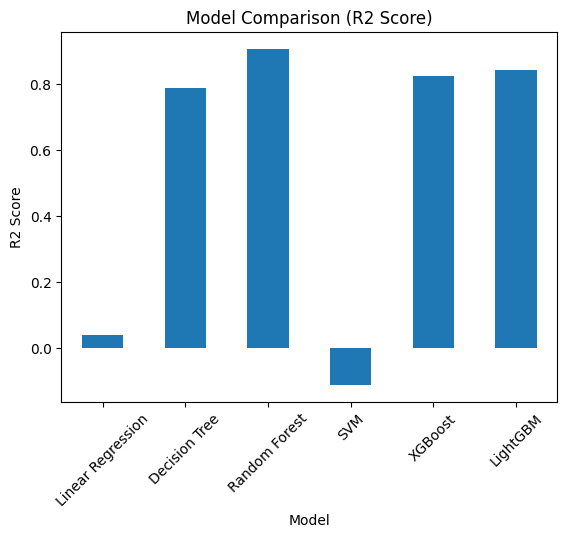

In [103]:
import matplotlib.pyplot as plt

results_df.set_index("Model")["R2 Score"].plot(kind='bar')
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

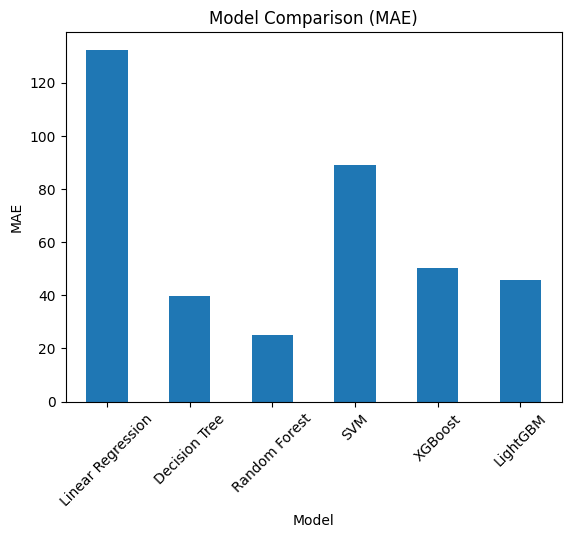

In [104]:
results_df.set_index("Model")["MAE"].plot(kind='bar')
plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()